In [72]:
import pandas as pd
from pathlib import Path
import ast
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

## Ingestao dos dados

In [2]:
data_source = Path(r"C:\Users\dougl\OneDrive\Área de Trabalho\POS\pratica do que aprendi\modulo01-fundamentos-de-ia-e-llms-para-programadores\exemplo-01\Redes Neurais\data\Bank_churn.csv")


In [3]:
df = pd.read_csv(data_source)

## Exploracao dos dados

In [4]:
# df.head()

In [5]:
# df.columns

In [6]:
# df["Geography:str,Gender:str"].head(10)

In [7]:
# df["Exited"].value_counts()

In [8]:
# df["Rating"].value_counts()

In [9]:
# df.isnull().sum()

In [10]:
# df["Geography:str,Gender:str"].value_counts()

In [11]:
# df["Age"].describe()

In [12]:
# df["EstimatedSalary"].describe()

In [13]:
# df["Age"].head(20).tolist()

In [14]:
# df["EstimatedSalary"].head(20).tolist()

In [15]:
# df["Age"] = pd.to_numeric(df["Age"], errors="coerce")
# df["EstimatedSalary"] = pd.to_numeric(df["EstimatedSalary"], errors="coerce")

In [16]:
# df[["Age", "EstimatedSalary"]].dtypes

In [17]:
# df.isnull().sum()

## Aqui comecamos a criar os dataframes de tranformacao

In [18]:
df_model = df[
    [
        "CreditScore",
        "Age",
        "Tenure",
        "Balance",
        "NumOfProducts",
        "HasCrCard",
        "IsActiveMember",
        "EstimatedSalary",
        "Geography:str,Gender:str",
        "Exited"
    ]
].copy()

In [19]:
ast.literal_eval(df_model["Geography:str,Gender:str"].iloc[0])

{'Geography': 'Paris-France', 'Gender': 'Male'}

In [20]:
df_model["Geography"]= df_model["Geography:str,Gender:str"].apply(
    lambda x: ast.literal_eval(x)["Geography"]
)

df_model["Gender"]= df_model["Geography:str,Gender:str"].apply(
    lambda x: ast.literal_eval(x)["Gender"]
)

In [21]:
df_model["Geography"].value_counts(dropna=False)

Geography
Paris-France     93778
Madrid-Spain     36050
Berlin-Gernay    34461
nan                745
Name: count, dtype: int64

In [22]:
df_model["Gender"].value_counts(dropna=False)

Gender
Male      88497
Female    68322
nan        8215
Name: count, dtype: int64

In [23]:
df_model["Gender"].isna().sum()

np.int64(0)

In [24]:
df_model["Gender"].dtype

<StringDtype(storage='python', na_value=nan)>

In [25]:
df_model["Gender"] = df_model["Gender"].replace("nan", pd.NA)
df_model["Geography"] = df_model["Geography"].replace("nan", pd.NA)

In [26]:
df_model[["Gender", "Geography"]].isna().sum()

Gender       8215
Geography     745
dtype: int64

In [27]:
df_model["Geography"] = df_model["Geography"].replace(
    "Berlin-Gernay", "Berlin-Germany"
)

In [28]:
df_model["Geography"].value_counts(dropna = False)

Geography
Paris-France      93778
Madrid-Spain      36050
Berlin-Germany    34461
NaN                 745
Name: count, dtype: int64

In [29]:
df_model["Gender"] = df_model["Gender"].fillna("Unknown")
df_model["Geography"] = df_model["Geography"].fillna("Unknown")

In [30]:
df_model = pd.get_dummies(
    df_model,
    columns = ["Geography", "Gender"]
)

In [31]:
df_model = df_model.drop(columns=["Geography:str,Gender:str"])

In [32]:
age_numeric = pd.to_numeric(
    df_model["Age"],
    errors="coerce"
)

In [33]:
age_clean = age_numeric.where(
    age_numeric.between(18, 100)
)

In [34]:
df_model["Age"] = age_clean

In [35]:
df_model["EstimatedSalary"] = pd.to_numeric(
    df_model["EstimatedSalary"],
    errors = "coerce"
)

In [36]:
x = df_model.drop(columns="Exited")
y = df_model["Exited"]

In [37]:
X_train, X_test, Y_train, Y_test = train_test_split(
    x,
    y,
    test_size = 0.2,
    random_state = 42
)

In [38]:
imputer = SimpleImputer(strategy="median")

In [39]:
numeric_columns =[
    "CreditScore",
    "Age",
    "Tenure",
    "Balance",
    "NumOfProducts",
    "HasCrCard",
    "IsActiveMember",
    "EstimatedSalary"
]

In [40]:
imputer.fit(X_train[numeric_columns])

,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](8,)","['CreditScore','Age','Tenure',...,'HasCrCard','IsActiveMember', 'EstimatedSalary']"
indicator_ indicator_: :class:`~sklearn.impute.MissingIndicator`Indicator used to add binary indicators for missing values.`None` if `add_indicator=False`.,NoneType,None
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
"statistics_ statistics_: array of shape (n_features,)The imputation fill value for each feature.Computing statistics can result in `np.nan` values.During :meth:`transform`, features corresponding to `np.nan`statistics will be discarded.","ndarray[float64](8,)","[ 660. , 37. , 5. ,..., 1. , 0. ,117977.45]"


In [41]:
X_train[numeric_columns] = imputer.transform(
    X_train[numeric_columns]
)

In [42]:
X_test[numeric_columns] = imputer.transform(
    X_test[numeric_columns]
)

In [43]:
scaler = StandardScaler()

In [44]:
scaler.fit(X_train[numeric_columns])

StandardScaler()

In [45]:
X_train[numeric_columns] = scaler.transform(
    X_train[numeric_columns]
)

In [46]:
X_test[numeric_columns] = scaler.transform(
    X_test[numeric_columns]
)

In [47]:
X_train[numeric_columns].describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
count,1.320270e+05,1.320270e+05,1.320270e+05,1.320270e+05,1.320270e+05,1.320270e+05,1.320270e+05,1.320270e+05
mean,-4.649874e-16,5.682103e-16,1.146323e-16,-1.397115e-16,1.765230e-17,2.497155e-17,-3.541224e-17,-3.246032e-16
std,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00
min,-3.837305e+00,-2.309653e+00,-1.814223e+00,-8.658652e-01,-1.048229e+00,-1.771001e+00,-9.736037e-01,-2.274949e+00
25%,-7.354596e-01,-6.992071e-01,-7.307820e-01,-8.658652e-01,-1.048229e+00,5.646525e-01,-9.736037e-01,-7.453400e-01
50%,4.000170e-02,-1.240477e-01,-8.487955e-03,-8.658652e-01,7.915857e-01,5.646525e-01,-9.736037e-01,1.040789e-01
75%,6.653737e-01,4.511118e-01,7.138061e-01,1.031134e+00,7.915857e-01,5.646525e-01,1.027112e+00,8.179184e-01
max,2.416415e+00,6.202706e+00,1.797247e+00,3.137417e+00,4.471215e+00,5.646525e-01,1.027112e+00,1.758083e+00


In [48]:
X_train["Age"].sort_values().head(10)


145528   -2.309653
145537   -2.309653
36740    -2.309653
141525   -2.309653
28451    -2.309653
36116    -2.309653
140512   -2.309653
89613    -2.309653
97963    -2.309653
63915    -2.309653
Name: Age, dtype: float64

In [49]:
df_model[df_model["Age"] < 0].value_counts().sort_index()

Series([], Name: count, dtype: int64)

In [50]:
df[df["Age"].astype(str).str.contains("-", na=False)]["Age"].value_counts().head(20)

Age
-3900.0           9
-350.0            8
-3800.0           7
-34000.0          7
-3600.0           7
-290.0            7
-38000.0          7
37.0 year-old     7
29.0 years-old    7
-390.0            6
-3700.0           6
-43000.0          6
-400.0            6
33.0 year-old     5
35.0 year-old     5
38.0 years-old    5
41.0 years-old    5
40.0 year-old     4
-460.0            4
33.0 years-old    4
Name: count, dtype: int64

In [61]:
model = tf.keras.Sequential([
    tf.keras.Input(shape=(15,)),
    tf.keras.layers.Dense(16, activation = 'relu'),
    tf.keras.layers.Dense(8, activation = 'relu'),
    tf.keras.layers.Dense(1, activation = 'sigmoid')
])

In [63]:
model.compile(
    optimizer = "Adam",
    loss = "binary_crossentropy",
    metrics = ["accuracy"]
)

In [64]:
history = model.fit(
    X_train,
    Y_train,
    epochs = 10,
    batch_size = 32,
    validation_split = 0.2
)

Epoch 1/10
3301/3301 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - accuracy: 0.8378 - loss: 0.3739 - val_accuracy: 0.8562 - val_loss: 0.3420
Epoch 2/10
3301/3301 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.8571 - loss: 0.3391 - val_accuracy: 0.8585 - val_loss: 0.3394
Epoch 3/10
3301/3301 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.8583 - loss: 0.3367 - val_accuracy: 0.8592 - val_loss: 0.3387
Epoch 4/10
3301/3301 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.8588 - loss: 0.3356 - val_accuracy: 0.8587 - val_loss: 0.3365
Epoch 5/10
3301/3301 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.8590 - loss: 0.3350 - val_accuracy: 0.8599 - val_loss: 0.3357
Epoch 6/10
3301/3301 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.8595 - loss: 0.3347 - val_accuracy: 0.8602 - val_loss: 0.3350
Epoch 7/10
3301/3301 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.8593 - loss: 0.3342 - val_accuracy: 0.8595 - val_loss: 0.3363
Epoch 8/10
3301/3301 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8599 - loss: 0.3340 - 

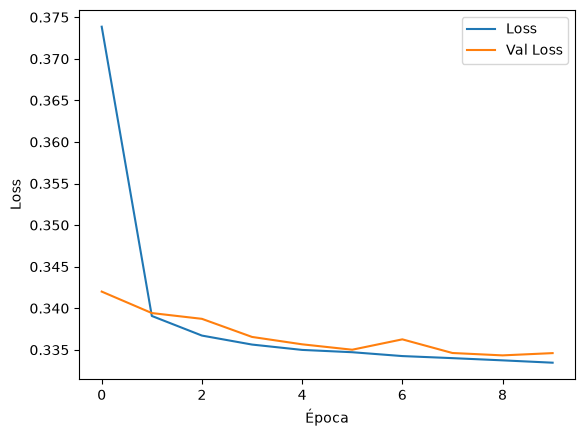

In [70]:
plt.plot(history.history["loss"], label="Loss")
plt.plot(history.history["val_loss"], label="Val Loss")

plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [71]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    Y_test
)

1032/1032 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8605 - loss: 0.3309


In [74]:
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob >= 0.5).astype(int)

confusion_matrix(Y_test, y_pred)

1032/1032 ━━━━━━━━━━━━━━━━━━━━ 1s 757us/step


array([[24834,  1218],
       [ 3386,  3569]])

In [75]:
recall = 3569 / (3569 + 3386)
print(recall)

0.513156002875629


In [76]:
precision = 3569 / (3569 + 1218)
print(precision)

0.7455608940881554
